# DQN Experiments

This notebook runs the Phase 1 Deep Q-Network baseline for the static maze environment.

It follows the same flow as the Q-learning notebook:

- environment inspection
- DQN training
- greedy evaluation
- metrics summary
- model saving
- learning, success, Q-value, and policy visualizations

DQN uses the full flat maze observation as neural-network input instead of a tabular state index.

## 1. Notebook Setup

Run this first so imports work whether the notebook is opened from the project root or from the `notebooks/` folder.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/hiba/Desktop/maze project/Maze-and-Path-Finding')

In [ ]:
%pip install matplotlib seaborn scikit-learn pandas numpy torch

In [7]:
import json
from dataclasses import replace
from itertools import product
from typing import Any

import numpy as np
import pandas as pd

from src.agents.dqn_agent import DQNAgent, DQNConfig, MLPQNetwork, ReplayBuffer
from src.env import MazeEnv, ACTIONS, ACTION_NAMES, LEVEL_SIZES, DIFFICULTY_SPECS
from src.training.trainer_dqn import train_dqn, rollout_greedy_path, q_table_from_dqn
from src.training.evaluator import evaluate_dqn
from src.utils.metrics import MetricsTracker
from src.utils.seed import set_global_seed
from src.utils.io import DIRS, ensure_dirs, figure_path, save_dqn, save_metrics
from src.visualization.maze_viz import plot_maze
from src.visualization.heatmaps import plot_q_heatmap
from src.visualization.plots import plot_learning_curve, plot_success_curve
from src.visualization.policy_maps import plot_policy_arrows

## 2. Experiment Configuration

For a fast test, set `EPISODES = 10` or `50`. For a more meaningful DQN baseline, use `EPISODES = 1000` or more. Start with `small`; `large` is much slower for DQN.

In [35]:
LEVEL = "small"  # tiny=8, small=10, medium=20, large=50
SIZE = LEVEL_SIZES[LEVEL]
DIFFICULTY = "hard"  # easy, medium, hard
SEED = 42
EPISODES = 2000  # increased from 500
LOG_EVERY = 50
LEARNING_RATE = 1e-3
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.999  # slower decay, more exploration
BUFFER_SIZE = 50_000
BATCH_SIZE = 64
TARGET_UPDATE_EVERY = 250
WARMUP_STEPS = 200  # start learning earlier
HIDDEN_DIMS = (128, 128)
DEVICE = "cpu"
RUN_ID = f"dqn_{LEVEL}_{DIFFICULTY}_seed{SEED}"
RUN_ID

'dqn_small_hard_seed42'

## 3. Create and Inspect the Maze Environment

In [36]:
set_global_seed(SEED)

env = MazeEnv(level=LEVEL, difficulty=DIFFICULTY, seed=SEED)
env.action_space.seed(SEED)

obs, info = env.reset()

print("Level:", env.level)
print("Difficulty:", env.difficulty)
print("Maze size:", env.size)
print("Observation shape:", obs.shape)
print("Action space:", env.action_space.n)
print("Start:", env.start_pos)
print("Goal:", env.goal_pos)
print("Max steps:", env.max_steps)
print("Optimal path length:", info["optimal_path_len"])
print("Actions:", ACTION_NAMES)

Level: small
Difficulty: hard
Maze size: 10
Observation shape: (100,)
Action space: 4
Start: (0, 0)
Goal: (9, 9)
Max steps: 400
Optimal path length: 28
Actions: {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}


In [37]:
env.maze

array([[0, 0, 1, 1, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 1],
       [1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
       [0, 1, 1, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]], dtype=int32)

Display the generated maze with dark walls, white rooms/free cells, blue start, green goal, and the BFS shortest path in orange.


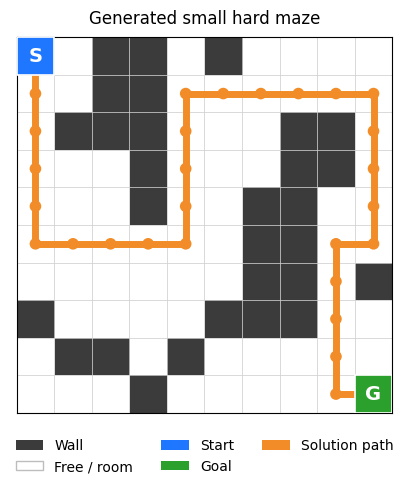

In [38]:
try:
    fig, ax = plot_maze(
        env,
        title=f"Generated {LEVEL} {DIFFICULTY} maze",
        save_path=figure_path(RUN_ID, "maze_layout"),
        show=True,
    )
except Exception as exc:
    print("Plot skipped:", exc)


## 4. Initialize DQN Agent

In [39]:
agent = DQNAgent(
    obs_dim=env.observation_space.shape[0],
    n_actions=env.action_space.n,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    buffer_size=BUFFER_SIZE,
    batch_size=BATCH_SIZE,
    target_update_every=TARGET_UPDATE_EVERY,
    warmup_steps=WARMUP_STEPS,
    hidden_dims=HIDDEN_DIMS,
    seed=SEED,
    device=DEVICE,
)


agent

## 5. Train DQN

In [40]:
result = train_dqn(
    env=env,
    agent=agent,
    episodes=EPISODES,
    log_every=LOG_EVERY,
)

summary = result.tracker.compute_summary()
summary

Episode    50/2000 | return=-34.486 | steps= 400 | success=0 | eps=0.952 | loss=0.0024 | rolling_success=n/a
Episode   100/2000 | return=-23.722 | steps= 400 | success=0 | eps=0.906 | loss=0.0014 | rolling_success=6.00%
Episode   150/2000 | return= -9.205 | steps= 369 | success=1 | eps=0.862 | loss=0.0067 | rolling_success=7.00%
Episode   200/2000 | return=-27.310 | steps= 400 | success=0 | eps=0.819 | loss=0.0097 | rolling_success=5.00%
Episode   250/2000 | return=-14.154 | steps= 400 | success=0 | eps=0.779 | loss=0.0053 | rolling_success=8.00%
Episode   300/2000 | return= -4.293 | steps= 241 | success=1 | eps=0.741 | loss=0.0260 | rolling_success=21.00%
Episode   350/2000 | return=  2.381 | steps= 145 | success=1 | eps=0.705 | loss=0.1900 | rolling_success=33.00%
Episode   400/2000 | return=-14.453 | steps= 400 | success=0 | eps=0.671 | loss=0.0405 | rolling_success=48.00%
Episode   450/2000 | return=-14.453 | steps= 400 | success=0 | eps=0.638 | loss=0.0282 | rolling_success=33.00%

{'success_rate': 1.0,
 'mean_return': 9.6993,
 'std_return': 0.28,
 'mean_steps_to_goal': 32.62,
 'std_steps_to_goal': 2.81,
 'convergence_episode': 584,
 'sample_efficiency': 200768.0,
 'path_optimality': 0.8584,
 'optimal_path_len': 28,
 'total_episodes': 2000}

## 6. Greedy Evaluation

In [41]:
# 1. Check if agent actually learned anything
import torch
obs, info = env.reset()
obs_tensor = torch.FloatTensor(obs).unsqueeze(0)
q_values = agent.q_network(obs_tensor)
print(q_values)

tensor([[7.3140, 7.7296, 7.3794, 7.5055]], grad_fn=<AddmmBackward0>)


In [42]:
# 2. Check the greedy path length
greedy_path = rollout_greedy_path(env, agent)
print("Path length:", len(greedy_path))
print("First 10 steps:", greedy_path[:10])
print("Last 10 steps:", greedy_path[-10:])
print("Goal pos:", env.goal_pos)

Path length: 29
First 10 steps: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (5, 2), (5, 3), (5, 4)]
Last 10 steps: [(2, 9), (3, 9), (4, 9), (4, 8), (5, 8), (6, 8), (7, 8), (8, 8), (9, 8), (9, 9)]
Goal pos: (9, 9)


In [43]:
# 3. Check what the env returns on reset
obs, info = env.reset()
print("Start pos:", env.start_pos)
print("Goal pos:", env.goal_pos)
print("Obs shape:", obs.shape)
print("Obs sample:", obs[:10])

Start pos: (0, 0)
Goal pos: (9, 9)
Obs shape: (100,)
Obs sample: [2. 1. 0. 0. 1. 0. 1. 1. 1. 1.]


In [44]:
agent.epsilon = 0.0
eval_result = evaluate_dqn(env, agent, episodes=100)

eval_summary = {
    "eval_success_rate": round(eval_result.success_rate, 4),
    "eval_mean_return": round(eval_result.mean_return, 4),
    "eval_mean_steps": round(eval_result.mean_steps, 2),
}
eval_summary

{'eval_success_rate': 1.0, 'eval_mean_return': 9.973, 'eval_mean_steps': 28.0}

## 7. Save Model and Metrics

In [45]:
summary.update(
    {
        **eval_summary,
        "maze_size": env.size,
        "level": env.level,
        "difficulty": env.difficulty,
        "max_steps": env.max_steps,
        "loss_count": len(result.losses),
    }
)

model_path = save_dqn(agent.q_network, RUN_ID)
metrics_path = save_metrics(
    {
        "episodes": result.tracker.episodes_arr,
        "rewards": result.tracker.rewards,
        "steps": result.tracker.steps_arr,
        "success": result.tracker.success_arr,
        "losses": np.asarray(result.losses, dtype=float),
    },
    RUN_ID,
)

paths_json = DIRS["metrics"] / f"{RUN_ID}_paths.json"
paths_json.write_text(
    json.dumps({name: [[int(r), int(c)] for r, c in path] for name, path in result.paths.items()}, indent=2),
    encoding="utf-8",
)

summary_path = DIRS["logs"] / f"{RUN_ID}_notebook_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

model_path, metrics_path, paths_json, summary_path

  [io] DQN model saved -> /home/hiba/Desktop/maze project/Maze-and-Path-Finding/models/dqn/dqn_small_hard_seed42.pt
  [io] metrics saved -> /home/hiba/Desktop/maze project/Maze-and-Path-Finding/results/metrics/dqn_small_hard_seed42_metrics.npz


(PosixPath('/home/hiba/Desktop/maze project/Maze-and-Path-Finding/models/dqn/dqn_small_hard_seed42.pt'),
 PosixPath('/home/hiba/Desktop/maze project/Maze-and-Path-Finding/results/metrics/dqn_small_hard_seed42_metrics.npz'),
 PosixPath('/home/hiba/Desktop/maze project/Maze-and-Path-Finding/results/metrics/dqn_small_hard_seed42_paths.json'),
 PosixPath('/home/hiba/Desktop/maze project/Maze-and-Path-Finding/results/logs/dqn_small_hard_seed42_notebook_summary.json'))

## 8. Learning Curves

/tmp/ipykernel_17819/2468425298.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_17819/2468425298.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


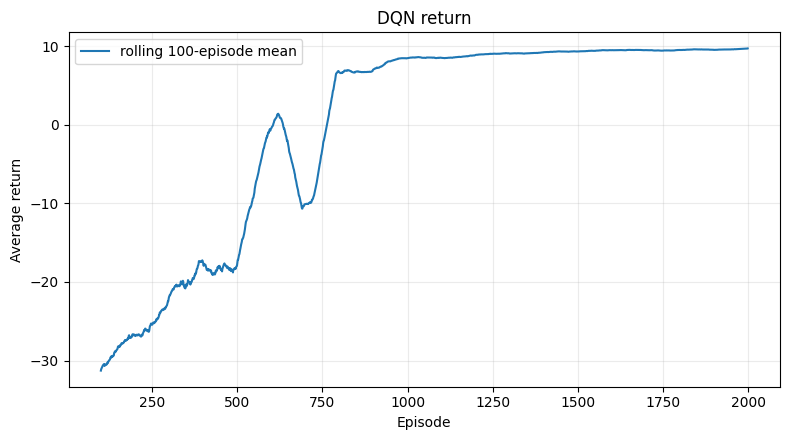

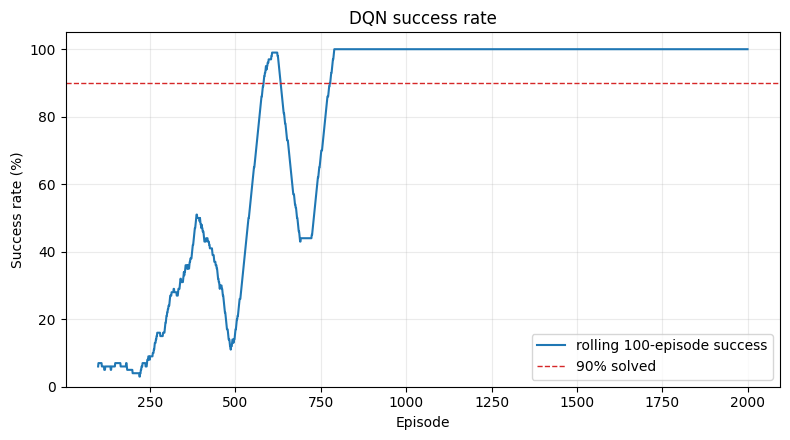

In [46]:
try:
    fig = plot_learning_curve(result.tracker.rewards, title="DQN return")
    fig.savefig(figure_path(RUN_ID + "_notebook", "learning_curve"), dpi=150)
    fig.show()

    fig = plot_success_curve(result.tracker.success_arr, title="DQN success rate")
    fig.savefig(figure_path(RUN_ID + "_notebook", "success_curve"), dpi=150)
    fig.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 9. Q-Value Heatmap and Greedy Policy

The network is evaluated once for every possible agent cell to produce a Q-table-like array for the existing visualization helpers.

In [47]:
q_values_by_cell = q_table_from_dqn(env, agent)
q_values_by_cell.shape

(100, 4)

/tmp/ipykernel_17819/1429577060.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_17819/1429577060.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


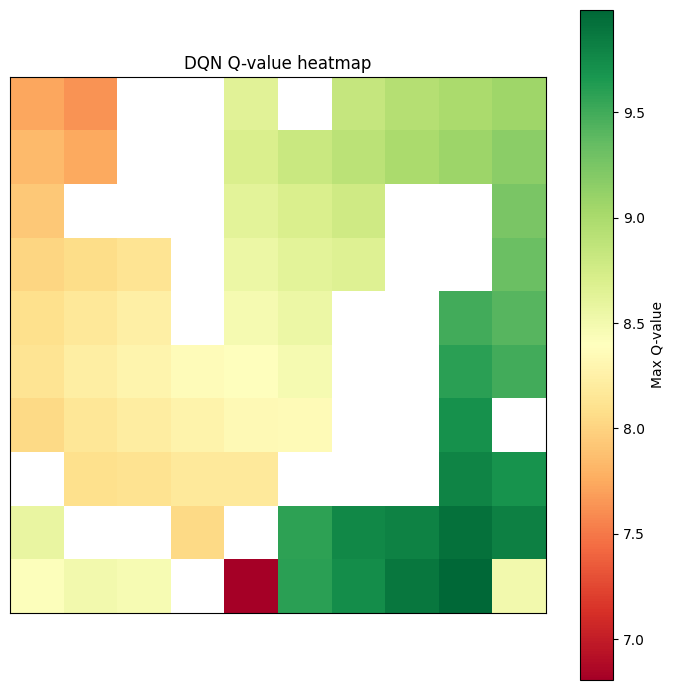

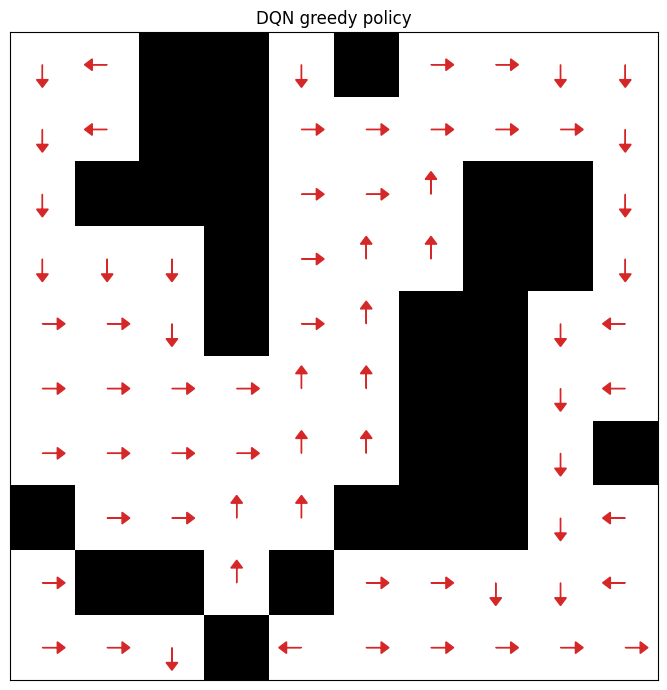

In [48]:
try:
    fig = plot_q_heatmap(q_values_by_cell, env.maze, title="DQN Q-value heatmap")
    fig.savefig(figure_path(RUN_ID + "_notebook", "q_heatmap"), dpi=150)
    fig.show()

    fig = plot_policy_arrows(q_values_by_cell, env.maze, title="DQN greedy policy")
    fig.savefig(figure_path(RUN_ID + "_notebook", "policy_map"), dpi=150)
    fig.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 10. Greedy Path After Training

In [49]:
greedy_path = rollout_greedy_path(env, agent)
len(greedy_path), greedy_path[:10], greedy_path[-10:]

(29,
 [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (4, 1),
  (4, 2),
  (5, 2),
  (5, 3),
  (5, 4)],
 [(2, 9),
  (3, 9),
  (4, 9),
  (4, 8),
  (5, 8),
  (6, 8),
  (7, 8),
  (8, 8),
  (9, 8),
  (9, 9)])

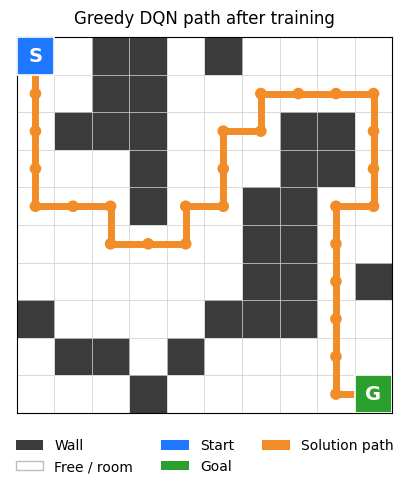

In [50]:
try:
    fig, ax = plot_maze(
        env,
        path=greedy_path,
        show_solution=False,
        title="Greedy DQN path after training",
        save_path=figure_path(RUN_ID, "greedy_path"),
        show=True,
    )
except Exception as exc:
    print("Plot skipped:", exc)
